# U.S. Naval Observatory Historical Data Processing

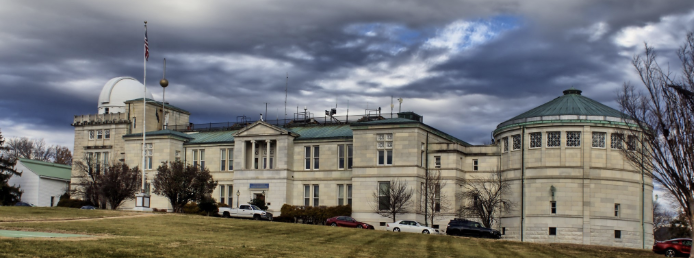

Imports a USNO/WDS 'MEASURES' text file from the U.S. Naval Observatory of historical Washington Star Catalogue Data and exports it as a CSV.

In [15]:
#imports

import re
from typing import Optional
import pandas as pd

For information on how to read the USNO/WDS 'MEASURES' file, please see the co-located datarequest key file. We thank Dr. Rachel Matson for providing us with this data.

In [13]:
def wds_measures_txt_to_csv(
    txt_path: str,
    out_csv_path: Optional[str] = None,
    empty_as_blank: bool = False
) -> pd.DataFrame:
    """
    Parse a USNO/WDS 'MEASURES' text file into a DataFrame (and optional CSV).
    """
    COLS = ['Epoch','PA','σ_PA','Sep','σ_Sep',
            'Mag_pri','σ_Mag_pri','Mag_sec','σ_Mag_sec',
            'λ (nm)','Δλ','n','N','Discoverer','Instrument','Note','Orbit Grade']

    def is_number_like(s: str) -> bool:
        try:
            float(s); return True
        except Exception:
            return False

    def looks_discoverer(tok: str) -> bool:
        # e.g., ElB2021, Izm2020, Gic1971, WIS2012, HJ_1847a
        return bool(re.match(r'^[A-Za-z][A-Za-z_]*\d', tok or ''))

    def looks_instrument(tok: str) -> bool:
        # short alnum: T, C, Pa, Hg, Eu, E2, Cu, Mb, Cl, Hw, ...
        return bool(re.match(r'^[A-Za-z0-9]{1,3}$', tok or ''))

    def maybe_int(tok: str) -> bool:
        try:
            float(tok); return True
        except Exception:
            return False

    rows: List[Dict[str, Any]] = []
    in_measures = False
    stop_sections = {"NOTES:", "REFERENCES:"}

    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            s = raw.strip()
            if not in_measures:
                if s.startswith("MEASURES"):
                    in_measures = True
                continue
            if not s or s.startswith("---"):
                continue
            if s in stop_sections:
                break

            parts = s.split()
            if not parts or not is_number_like(parts[0]):   # measurement rows start with epoch
                continue

            # normalize '.' → None
            parts = [None if p == '.' else p for p in parts]
            if len(parts) < 10:
                continue

            core = parts[:9]
            tail = parts[9:]

            grade = tail[-1]
            if not maybe_int(grade):
                continue

            layout0 = dict(
                instrument = tail[-2] if len(tail) >= 2 else None,
                discoverer = tail[-3] if len(tail) >= 3 else None,
                N = tail[-4] if len(tail) >= 4 else None,
                n = tail[-5] if len(tail) >= 5 else None,
                lambda_block = tail[:-5],
                note = None
            )
            
            layout1 = dict(
                instrument = tail[-3] if len(tail) >= 3 else None,
                discoverer = tail[-4] if len(tail) >= 4 else None,
                N = tail[-5] if len(tail) >= 5 else None,
                n = tail[-6] if len(tail) >= 6 else None,
                lambda_block = tail[:-6],
                note = tail[-2] if len(tail) >= 2 else None
            )

            def score_layout(L):
                sc = 0
                if looks_instrument(L['instrument'] or ''): sc += 1
                if looks_discoverer(L['discoverer'] or ''): sc += 1
                if maybe_int(L['N'] or ''): sc += 1
                if L['n'] is not None: sc += 1   # 'n' can be '0.4a', so just require presence
                return sc

            L = layout0 if score_layout(layout0) >= score_layout(layout1) else layout1

            lam = L['lambda_block'][0] if len(L['lambda_block']) >= 1 else None
            dlam = L['lambda_block'][1] if len(L['lambda_block']) >= 2 else None

            row = dict.fromkeys(COLS)
            for k, v in zip(['Epoch','PA','σ_PA','Sep','σ_Sep','Mag_pri','σ_Mag_pri','Mag_sec','σ_Mag_sec'], core):
                row[k] = v
            row['λ (nm)'] = lam
            row['Δλ'] = dlam
            row['n'] = None if L['n'] is None else str(L['n'])
            row['N'] = L['N']
            row['Discoverer'] = L['discoverer']
            row['Instrument'] = L['instrument']
            row['Note'] = L['note']
            row['Orbit Grade'] = grade
            rows.append(row)

    df = pd.DataFrame(rows, columns=COLS)

    # numeric-like columns (keep 'n' as string)
    for c in ['Epoch','PA','σ_PA','Sep','σ_Sep','Mag_pri','σ_Mag_pri','Mag_sec','σ_Mag_sec','λ (nm)']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['N'] = pd.to_numeric(df['N'], errors='coerce')
    df['Orbit Grade'] = pd.to_numeric(df['Orbit Grade'], errors='coerce')

    for c in ['Δλ','Discoverer','Instrument','Note','n']:
        df[c] = df[c].astype('string').replace({"None": pd.NA})

    # blanks for missing if requested
    df_out = df.astype(object).where(pd.notnull(df), '') if empty_as_blank else df
    if out_csv_path is not None:
        df_out.to_csv(out_csv_path, index=False, na_rep='')

    return df_out

Export the data frame to a CSV.

In [14]:
filename = "wds15368-5010"

df = wds_measures_txt_to_csv(filename + ".txt", filename + ".csv")